<a href="https://colab.research.google.com/github/ilya-agafonov/dsp-seminars/blob/agafonov_lab3/seminars/3_Agafonov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

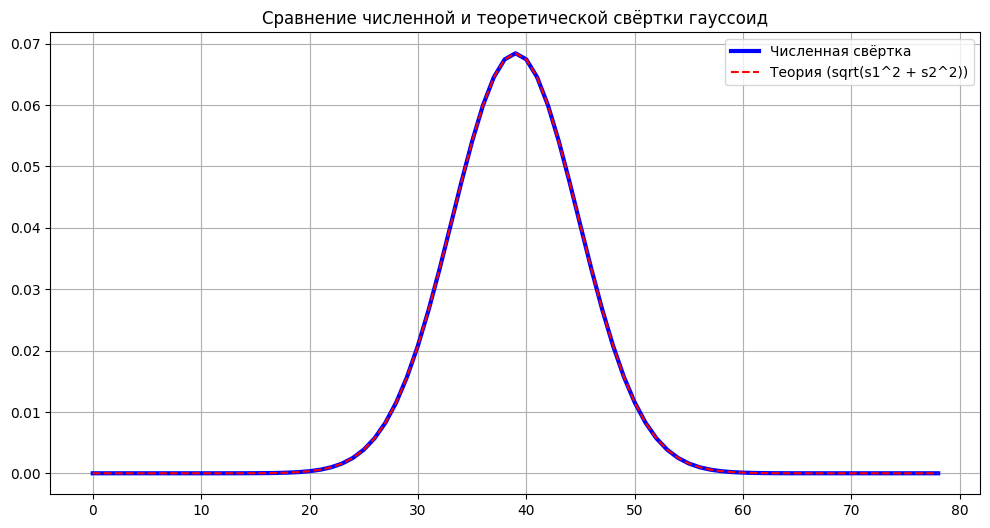

Среднеквадратичная ошибка (MSE): 9.14e-16


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

sigma1 = 3
sigma2 = 5
L1 = 10 * sigma1
L2 = 10 * sigma2

g1 = signal.windows.gaussian(L1, std=sigma1)
g1 /= np.sum(g1)
g2 = signal.windows.gaussian(L2, std=sigma2)
g2 /= np.sum(g2)

res_numeric = np.convolve(g1, g2, mode='full')

sigma_th = np.sqrt(sigma1**2 + sigma2**2)
L_res = len(res_numeric)
res_theory = signal.windows.gaussian(L_res, std=sigma_th)
res_theory /= np.sum(res_theory)

plt.figure(figsize=(12, 6))
plt.plot(res_numeric, 'b-', lw=3, label='Численная свёртка')
plt.plot(res_theory, 'r--', label='Теория (sqrt(s1^2 + s2^2))')
plt.title('Сравнение численной и теоретической свёртки гауссоид')
plt.legend()
plt.grid(True)
plt.show()

mse = np.mean((res_numeric - res_theory)**2)
print(f"Среднеквадратичная ошибка (MSE): {mse:.2e}")

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении σ форма свёртки становится шире и ниже, это означает более сильное сглаживание.



## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

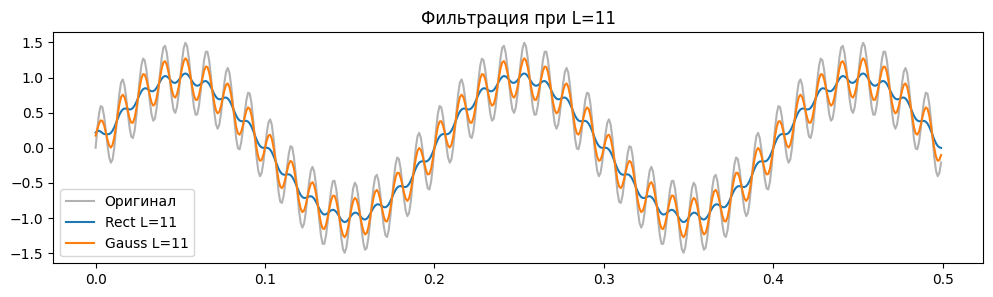

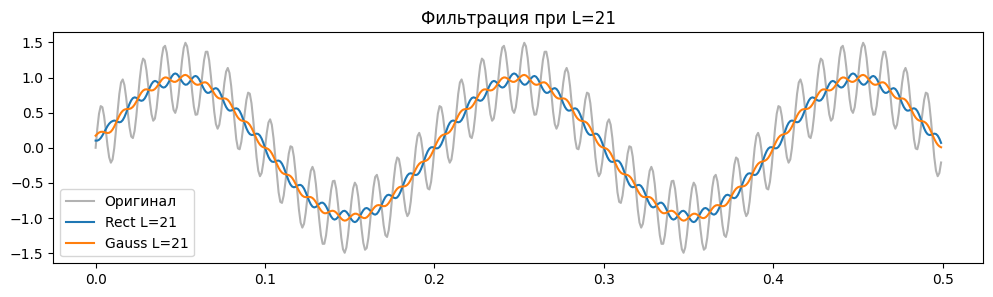

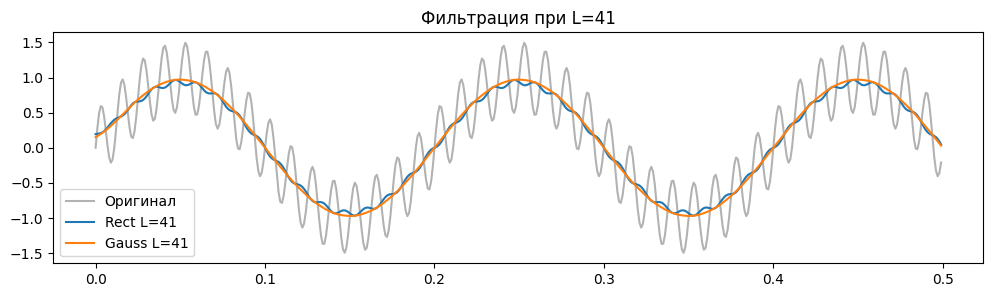

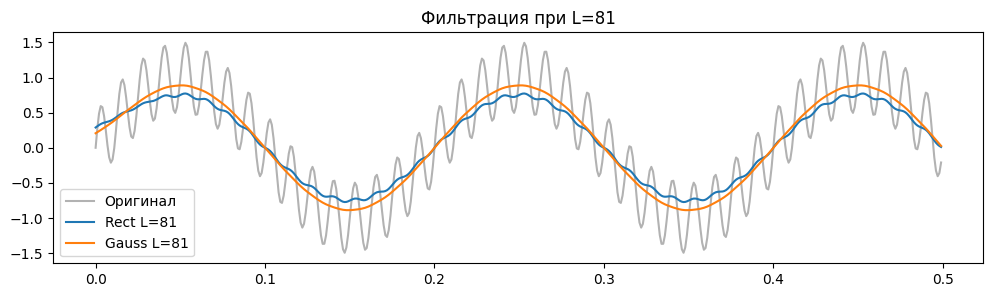

In [3]:
fs = 1000
t = np.arange(0, 2, 1/fs)
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)

lengths = [11, 21, 41, 81]

for L in lengths:
    h_rect = signal.windows.boxcar(L)
    h_rect /= np.sum(h_rect)

    h_gauss = signal.windows.gaussian(L, std=L/5)
    h_gauss /= np.sum(h_gauss)

    y_rect = np.convolve(x, h_rect, mode='same')
    y_gauss = np.convolve(x, h_gauss, mode='same')

    plt.figure(figsize=(12, 3))
    plt.plot(t[:500], x[:500], 'k', alpha=0.3, label='Оригинал')
    plt.plot(t[:500], y_rect[:500], label=f'Rect L={L}')
    plt.plot(t[:500], y_gauss[:500], label=f'Gauss L={L}')
    plt.title(f"Фильтрация при L={L}")
    plt.legend()
    plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?


*   Гауссовское окно обеспечивает качественное подавление высокой частоты. У прямоугольного окна побочные лепестки в частотной области (функция $sinc$), что может приводить к пропусканию части высокочастотной энергии на определенных частотах
*   При слишком большой длине окна (L > 81) полезный сигнал 5 Гц начинает заметно затухать(уменьшается более чем на 10%)
*  Увеличение длины окна всегда ведет к подавлению сигнала. Поскольку период 5 Гц равен 200 отсчётам, амплитуда начнет уменьшаться более чем на 10%, когда длина окна составит значительную часть этого периода







## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

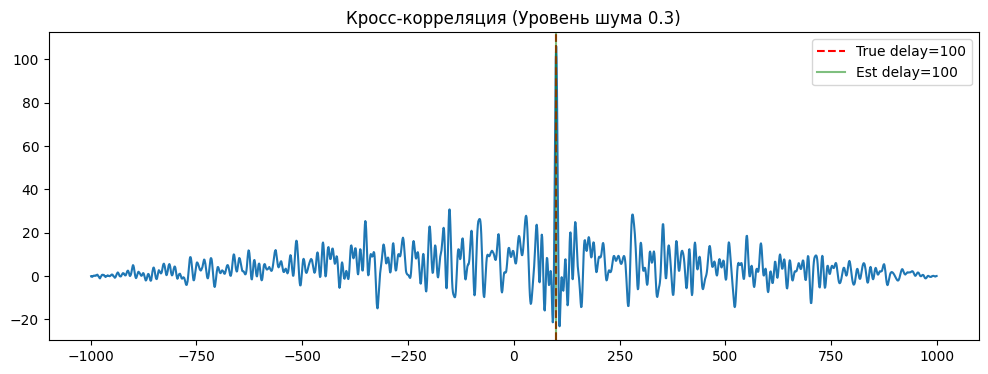

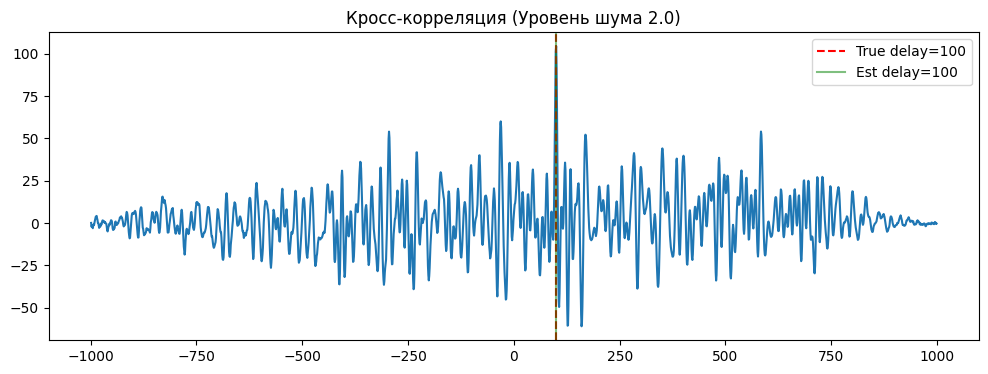

In [4]:
np.random.seed(42)
fs = 1000
t = np.arange(0, 1, 1/fs)
N = len(t)

x = np.zeros(N)
for _ in range(100):
    f = np.random.uniform(10, 100)
    a = np.random.uniform(0.5, 1.5)
    p = np.random.uniform(0, 2*np.pi)
    x += a * np.sin(2 * np.pi * f * t + p)

x = 2 * (x - x.min()) / (x.max() - x.min()) - 1

delay = 100
y = np.roll(x, delay)
noise_levels = [0.3, 2.0]

for nl in noise_levels:
    y_noisy = y + nl * np.random.randn(N)

    corr = np.correlate(y_noisy, x, mode='full')
    lags = np.arange(-N + 1, N)
    est_delay = lags[np.argmax(corr)]

    plt.figure(figsize=(12, 4))
    plt.plot(lags, corr)
    plt.axvline(delay, color='r', linestyle='--', label=f'True delay={delay}')
    plt.axvline(est_delay, color='g', alpha=0.5, label=f'Est delay={est_delay}')
    plt.title(f"Кросс-корреляция (Уровень шума {nl})")
    plt.legend()
    plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

*   При высоком уровне шума (SNR < 1) корреляционные пики тонут в шуме. Ложные пики появляются из-за случайных совпадений фаз шума с сигналом, особенно если сигнал имеет периодические компоненты.
*   При высоком уровне шума случайные выбросы случайного сигнала могут совпасть по фазе с полезным сигналом, создавая локальный максимум, превышающий истинный.



## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

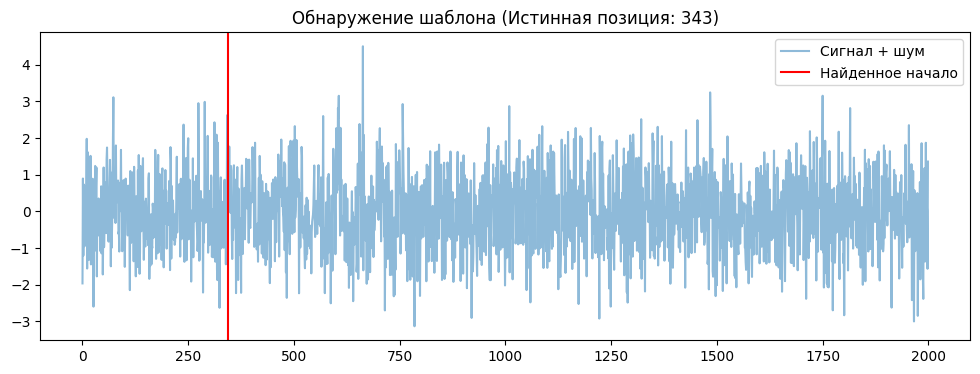

In [5]:
sigma = 100
t_temp = np.arange(-3*sigma, 3*sigma)
template = np.exp(-t_temp**2 / (2*sigma**2)) * np.sin(2 * np.pi * 20 * t_temp / 1000)

long_sig = np.random.randn(2000)
pos = np.random.randint(0, 1500)
A = 1.0
long_sig[pos : pos+len(template)] += A * template

corr = np.correlate(long_sig, template, mode='valid')
found_pos = np.argmax(corr)

plt.figure(figsize=(12, 4))
plt.plot(long_sig, alpha=0.5, label='Сигнал + шум')
plt.axvline(found_pos, color='r', label='Найденное начало')
plt.title(f"Обнаружение шаблона (Истинная позиция: {pos})")
plt.legend()
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

Результаты ухудшаются, когда амплитуда шаблона $A$ становится меньше 1(при единичной амплитуде шума). Резкая деградация точности наступает при SNR<0.5, когда энергия шума в полосе сигнала начинает маскировать корреляционный пик

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [6]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-12 21:23:16--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-12 21:23:17--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.05s   

2026-04-12 21:23:17 (130 MB/s) - ‘full_audio.wav’ saved [6990446/69

In [7]:
from scipy.io import wavfile
from IPython.display import Audio

# Загрузка (после выполнения ячейки с !wget в твоем ноутбуке)
fs_full, data_full = wavfile.read('full_audio.wav')
fs_frag, data_frag = wavfile.read('fragment.wav')

# Нормализация
x = data_full.astype(float) / 32768.0
y = data_frag.astype(float) / 32768.0

# Если стерео — берем один канал
if len(x.shape) > 1: x = x[:, 0]
if len(y.shape) > 1: y = y[:, 0]

# Корреляция
corr = np.correlate(x, y, mode='valid')
idx = np.argmax(corr)

print(f"Фрагмент найден на отметке: {idx} сэмплов ({idx/fs_full:.2f} сек)")

# Вырезаем и слушаем
found_segment = x[idx : idx + len(y)]
display(Audio(found_segment, rate=fs_full))

/tmp/ipykernel_33739/2641529729.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, data_full = wavfile.read('full_audio.wav')
/tmp/ipykernel_33739/2641529729.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, data_frag = wavfile.read('fragment.wav')


Фрагмент найден на отметке: 279235 сэмплов (6.33 сек)


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?



*   Нормализация нужна чтобы значение корреляции зависело от схожести формы сигналов, а не от их абсолютной громкости. Без этого громкий шум может дать более высокий пик, чем тихий полезный сигнал.

*


*   Новый пункт

